In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

In [5]:
weights = pd.read_csv(
    "./data/momentum_weights.csv",
    index_col=0,
    parse_dates=True
)

gross_returns = pd.read_csv(
    "./data/gross_strategy_and_benchmark_returns.csv",
    index_col=0,
    parse_dates=True
)

print("Weights shape:", weights.shape)
print("Gross returns shape:", gross_returns.shape)

gross_returns.head()

Weights shape: (139, 6)
Gross returns shape: (138, 2)


,Momentum Strategy (Gross),Equal-Weight Benchmark
Date,,
2015-02-28,0.0,0.005116
2015-03-31,0.0,-0.002479
2015-04-30,0.0,-0.015165
2015-05-31,0.0,0.006085
2015-06-30,0.0,-0.023315


In [7]:
turnover = weights.diff().abs().sum(axis=1) / 2

turnover.name = "One-Way Turnover"

turnover.tail(12)

#formula for Turnover at t = 1/2(sigma from i=1 until N for abs(Wi at t - Wi at t-1)

Date
2025-08-31    0.000000
2025-09-30    0.000000
2025-10-31    0.000000
2025-11-30    0.000000
2025-12-31    0.000000
2026-01-31    0.000000
2026-02-28    0.333333
2026-03-31    0.000000
2026-04-30    0.000000
2026-05-31    0.000000
2026-06-30    0.000000
2026-07-31    0.000000
Name: One-Way Turnover, dtype: float64

In [8]:
cost_per_turnover = 0.001  # 0.10% = 10 basis points

transaction_costs = turnover * cost_per_turnover

strategy_gross = gross_returns["Momentum Strategy (Gross)"]

strategy_net = strategy_gross - transaction_costs.reindex(
    strategy_gross.index
).fillna(0)

strategy_net.name = "Momentum Strategy (Net)"

results = pd.concat(
    [
        strategy_gross,
        strategy_net,
        gross_returns["Equal-Weight Benchmark"]
    ],
    axis=1
).dropna()

results.head()

,Momentum Strategy (Gross),Momentum Strategy (Net),Equal-Weight Benchmark
Date,,,
2015-02-28,0.0,0.0,0.005116
2015-03-31,0.0,0.0,-0.002479
2015-04-30,0.0,0.0,-0.015165
2015-05-31,0.0,0.0,0.006085
2015-06-30,0.0,0.0,-0.023315


In [9]:
cost_summary = pd.Series({
    "Average Monthly Turnover": turnover.loc[results.index].mean(),
    "Average Monthly Cost": transaction_costs.loc[results.index].mean(),
    "Total Estimated Cost Drag": transaction_costs.loc[results.index].sum()
})

cost_summary

print(f"Average monthly turnover: {cost_summary['Average Monthly Turnover']:.2%}")
print(f"Average monthly cost: {cost_summary['Average Monthly Cost']:.4%}")
print(f"Total estimated cost drag: {cost_summary['Total Estimated Cost Drag']:.2%}")

Average monthly turnover: 9.30%
Average monthly cost: 0.0093%
Total estimated cost drag: 1.28%


In [11]:
def performance_metrics(returns, periods_per_year=12):
    returns = returns.dropna()

    equity = (1 + returns).cumprod()
    years = len(returns) / periods_per_year

    total_return = equity.iloc[-1] - 1
    annualised_return = equity.iloc[-1] ** (1 / years) - 1
    annualised_volatility = returns.std() * np.sqrt(periods_per_year)

    sharpe_ratio = (
        returns.mean() / returns.std()
    ) * np.sqrt(periods_per_year)

    drawdown = equity / equity.cummax() - 1
    max_drawdown = drawdown.min()

    positive_months = (returns > 0).mean()

    return pd.Series({
        "Total Return": total_return,
        "Annualised Return": annualised_return,
        "Annualised Volatility": annualised_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown,
        "Positive Months": positive_months
    })

In [13]:
metrics = pd.DataFrame({
    column: performance_metrics(results[column])
    for column in results.columns
})

metrics

formatted_metrics = metrics.copy()

percentage_rows = [
    "Total Return",
    "Annualised Return",
    "Annualised Volatility",
    "Maximum Drawdown",
    "Positive Months"
]

formatted_metrics.loc[percentage_rows] = (
    formatted_metrics.loc[percentage_rows] * 100
)

formatted_metrics = formatted_metrics.round(2)

formatted_metrics

,Momentum Strategy (Gross),Momentum Strategy (Net),Equal-Weight Benchmark
Total Return,253.03,248.58,198.07
Annualised Return,11.59,11.47,9.96
Annualised Volatility,13.00,13.00,12.12
Sharpe Ratio,0.91,0.90,0.85
Maximum Drawdown,-24.82,-24.85,-25.01
Positive Months,60.87,60.87,65.22


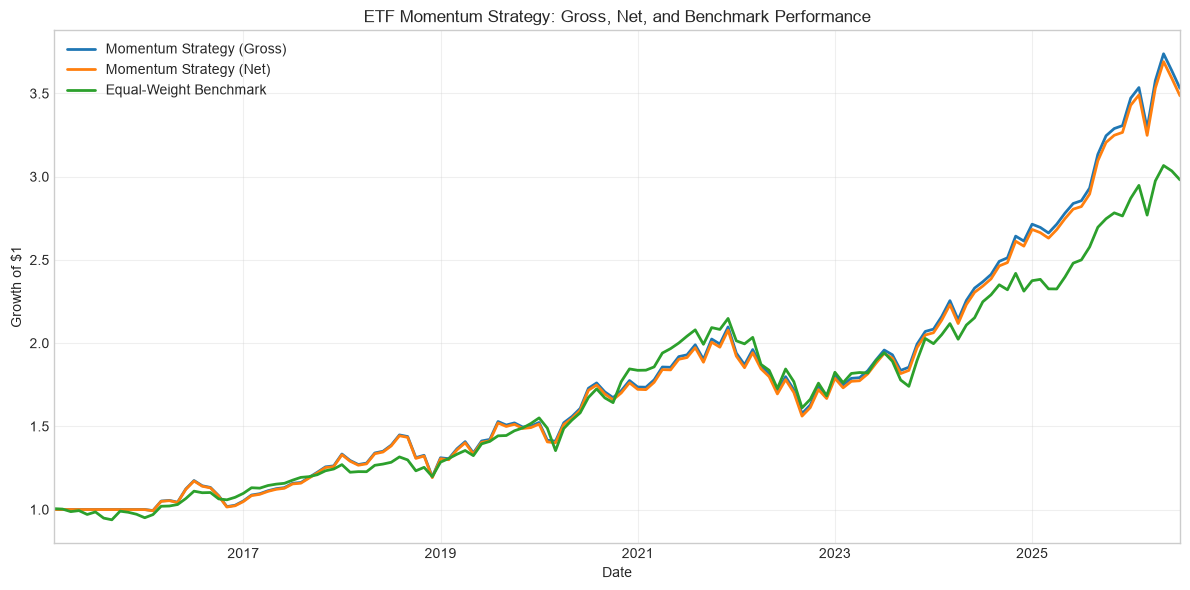

In [16]:
equity_curve = (1 + results).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))

equity_curve.plot(ax=ax, linewidth=2)

ax.set_title("ETF Momentum Strategy: Gross, Net, and Benchmark Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)

plt.tight_layout()

Path("./figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "./figures/equity_curve_gross_net_benchmark.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

#culmulative growth chart

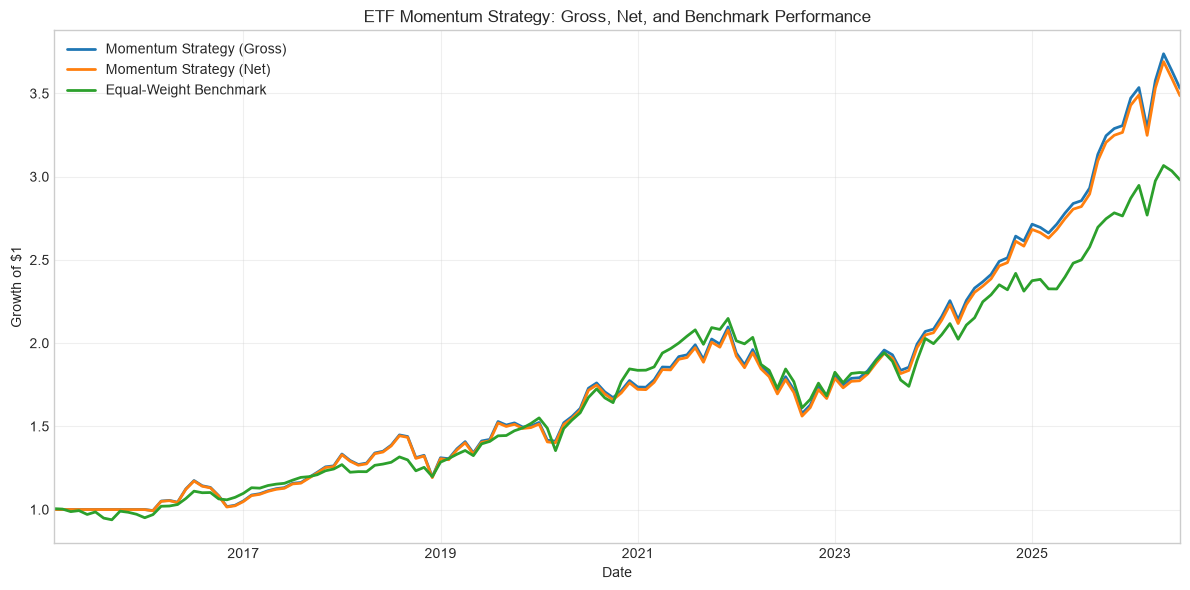

In [17]:
equity_curve = (1 + results).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))

equity_curve.plot(ax=ax, linewidth=2)

ax.set_title("ETF Momentum Strategy: Gross, Net, and Benchmark Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)

plt.tight_layout()

Path("./figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "./figures/equity_curve_gross_net_benchmark.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

#drawdown chart

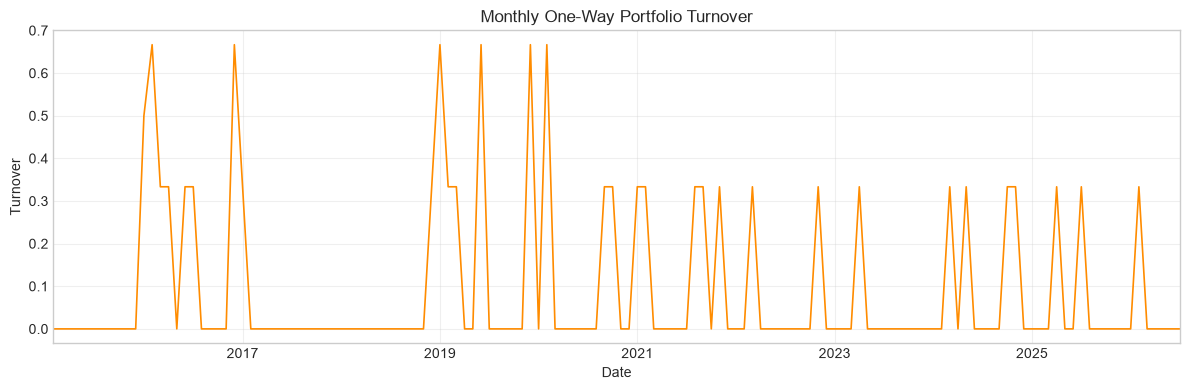

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))

turnover.loc[results.index].plot(
    ax=ax,
    color="darkorange",
    linewidth=1.2
)

ax.set_title("Monthly One-Way Portfolio Turnover")
ax.set_xlabel("Date")
ax.set_ylabel("Turnover")
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "./figures/monthly_turnover.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

#turnover chart

In [19]:
results.to_csv("./data/final_monthly_returns.csv")
metrics.to_csv("./data/performance_metrics.csv")
turnover.to_csv("./data/monthly_turnover.csv")
transaction_costs.to_csv("./data/monthly_transaction_costs.csv")

print("Saved final outputs successfully.")

Saved final outputs successfully.


In [20]:
#Momentum lookback: 12–1 months
#Number held: top 3 ETFs
#Rebalance: monthly
#Weights: equal
#Cost model: 10 bps × one-way turnover